# 02. Feature Engineering & Weight of Evidence

Weight of Evidence (WoE) transformation and Information Value (IV) analysis to prepare features for the scorecard model.

In [1]:
import logging
import pandas as pd
import sys
import os

# Ensure src module is importable from notebooks directory
sys.path.append(os.path.abspath('..'))

from src.data.preprocessing import LendingClubLoader
from src.features.woe_iv import WoEBinner

# Configure logging
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Initialized Feature Engineering Notebook.')

2026-05-23 12:08:46,333 - __main__ - INFO - Initialized Feature Engineering Notebook.


## Data Prep

Loading and splitting the dataset using LendingClubLoader.

In [2]:
logger.info('Loading dataset...')
loader = LendingClubLoader('../data/raw/accepted_2007_to_2018Q4.csv.gz', sample_size=200000, random_seed=42)
df = loader.load_and_clean()
X_train, X_test, y_train, y_test = loader.split(test_size=0.2)

2026-05-23 12:08:46,340 - __main__ - INFO - Loading dataset...
2026-05-23 12:08:46,343 - src.data.preprocessing - INFO - Loading data from ../data/raw/accepted_2007_to_2018Q4.csv.gz
2026-05-23 12:09:15,914 - src.data.preprocessing - INFO - Sampling 200000 records
2026-05-23 12:09:22,602 - src.data.preprocessing - INFO - Cleaning complete. Final shape: (118808, 24)
2026-05-23 12:09:22,609 - src.data.preprocessing - INFO - Class Balance:
2026-05-23 12:09:22,610 - src.data.preprocessing - INFO -   Fully Paid (0): 79.98%
2026-05-23 12:09:22,610 - src.data.preprocessing - INFO -   Charged Off (1): 20.02%
2026-05-23 12:09:22,683 - src.data.preprocessing - INFO - Split complete. Train: 95046, Test: 23762


## WoE/IV Calculation

Fitting the WoEBinner to compute WoE mappings and Information Value (IV) scores.

In [3]:
logger.info('Fitting WoEBinner on training data...')
binner = WoEBinner(fine_bins=20)
binner.fit(X_train, y_train)
logger.info('WoEBinner fitting complete.')

2026-05-23 12:09:22,697 - __main__ - INFO - Fitting WoEBinner on training data...
2026-05-23 12:09:22,700 - src.features.woe_iv - INFO - Fitting WoEBinner...
2026-05-23 12:09:22,974 - src.features.woe_iv - INFO - WoEBinner fitting complete.
2026-05-23 12:09:22,975 - __main__ - INFO - WoEBinner fitting complete.


In [4]:
iv_summary = binner.get_iv_summary()
display(iv_summary)

,feature,IV,power
0,sub_grade,0.496583,strong
1,grade,0.460307,strong
2,int_rate,0.459886,strong
3,fico_range_high,0.125420,medium
4,fico_range_low,0.125420,medium
5,dti,0.081477,weak
6,verification_status,0.054728,weak
7,loan_amnt,0.042520,weak
8,funded_amnt,0.042465,weak
9,installment,0.037794,weak


## Feature Analysis

Visualizing Weight of Evidence trends for the top 5 predictive features and identifying weak features to drop.

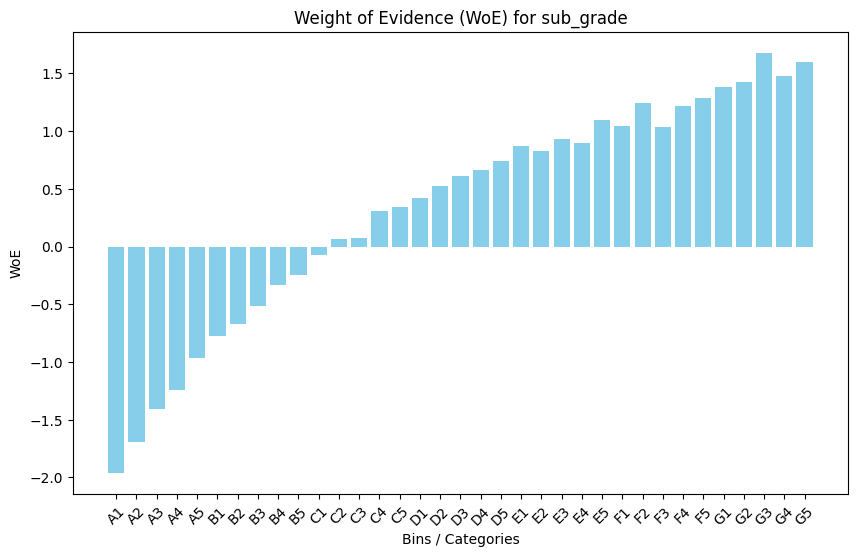

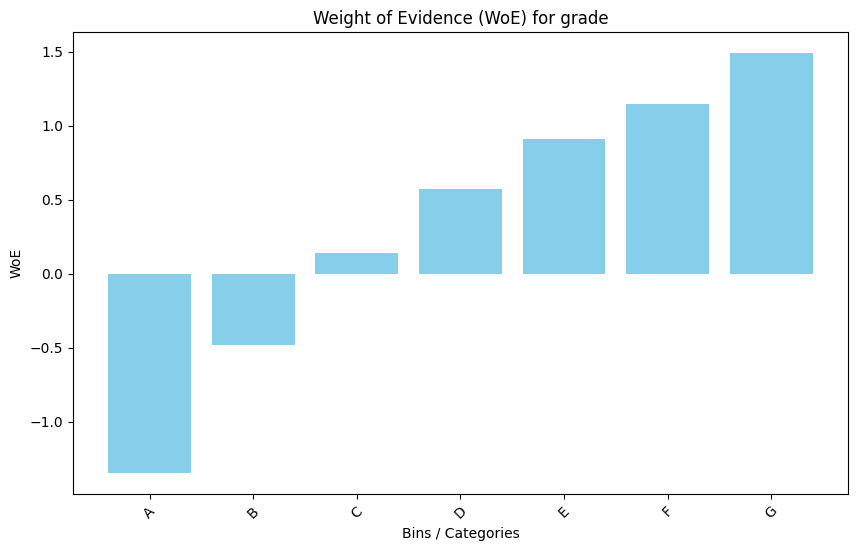

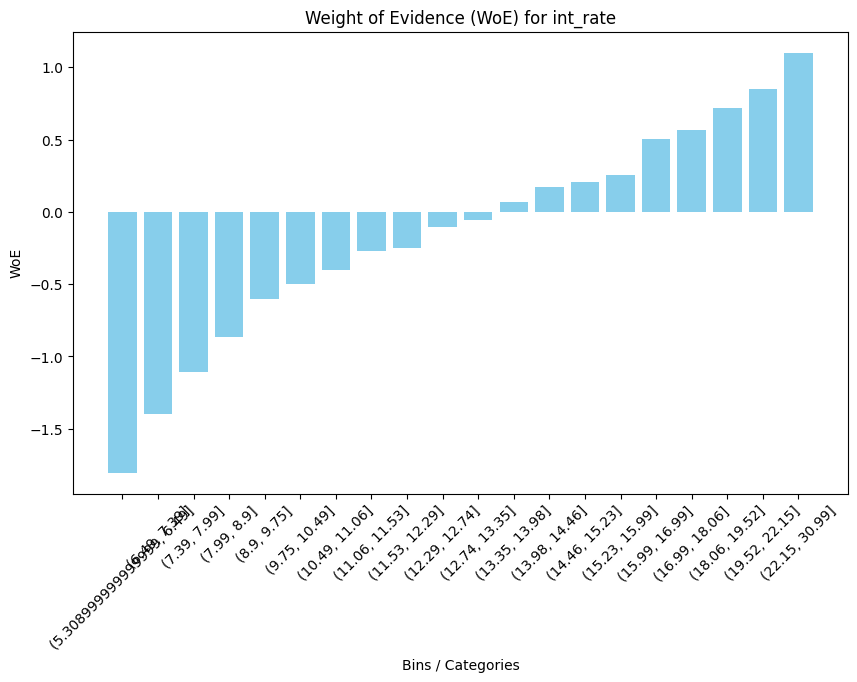

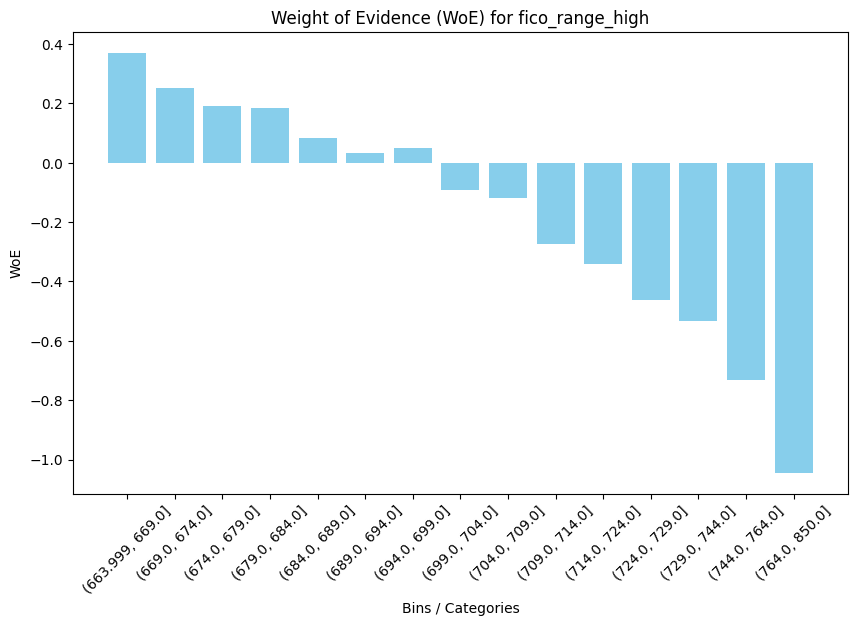

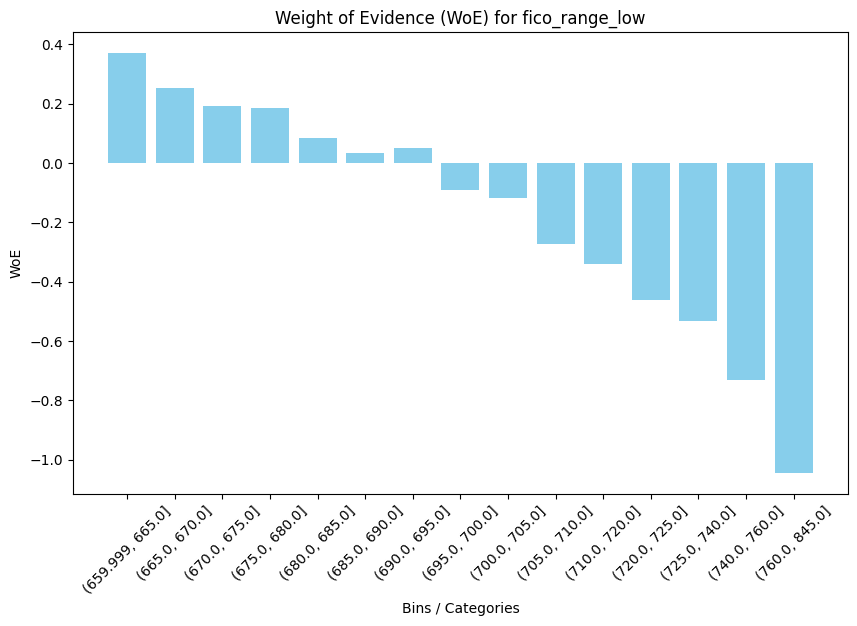

In [5]:
import matplotlib.pyplot as plt

top_5_features = iv_summary['feature'].head(5).tolist()
for feature in top_5_features:
    binner.plot_woe(feature)
    plt.show()

In [6]:
selected_features = binner.select_features(threshold=0.02)
dropped_features = [f for f in X_train.columns if f not in selected_features]

print('--- Feature Selection ---')
print(f'Total Features Selected: {len(selected_features)}')
print(f'Dropped Features (IV < 0.02): {dropped_features}')

--- Feature Selection ---
Total Features Selected: 13
Dropped Features (IV < 0.02): ['term', 'emp_length', 'purpose', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status', 'application_type']


## Transformation

Applying the WoE transformation to the training and testing sets, keeping only the selected features.

In [7]:
logger.info('Transforming data...')
X_train_woe = binner.transform(X_train)[selected_features]
X_test_woe = binner.transform(X_test)[selected_features]

print('Sample of Transformed Data:')
display(X_train_woe.head())

2026-05-23 12:09:23,884 - __main__ - INFO - Transforming data...


Sample of Transformed Data:


,loan_amnt,funded_amnt,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,dti,fico_range_low,fico_range_high,revol_util
2215525,-0.252788,-0.253995,0.169745,-0.389508,0.138017,0.075825,0.006308,-0.009650,0.053457,-0.377226,0.251074,0.251074,-0.023133
375485,0.056507,0.054382,-0.268469,0.168600,-0.480847,-0.247111,0.006308,0.201922,0.053457,0.049339,0.031803,0.031803,0.006517
324631,-0.252788,-0.253995,-0.600858,-0.244816,-0.480847,-0.675129,-0.161163,-0.037012,0.230164,-0.377226,-0.274052,-0.274052,0.073222
31495,-0.144468,-0.143239,-1.384924,-0.190779,-1.349518,-1.694976,-0.161163,-0.214566,0.053457,0.313569,-0.534389,-0.534389,0.182042
1781477,0.140971,0.144617,-0.500708,0.109638,-0.480847,-0.772439,-0.161163,-0.037012,0.230164,0.313569,-0.119017,-0.119017,0.101241


## Findings Summary

   Top Predictive Features*: 
   Dropped Features*: 
   WoE Trends*: 

In [8]:
import joblib

# Menyimpan WoE Encoder agar bisa dipakai oleh FastAPI
joblib.dump(binner, '../artifacts/woe_encoder_v1.joblib')

['../artifacts/woe_encoder_v1.joblib']